In [2]:
import math
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.io.wavfile import write

# Define note frequencies (middle octave - 4) Hz
BASE_NOTES_HERTZ = {
    'C': 262,
    'C#': 277,
    'D': 294,
    'D#': 311,
    'E': 330,
    'F': 349,
    'F#': 370,
    'G': 392,
    'G#': 415,
    'A': 440,
    'A#': 466,
    'B': 494
}


sine_Lookup = [
0, 2057, 4107, 6140, 8149, 10126, 12062, 13952, 15786, 17557, 19260, 20886, 22431, 23886, 25247, 26509, 27666, 28714, 29648, 30466, 31163, 31738, 32187, 32509, 32702,
32767, 32702, 32509, 32187, 31738, 31163, 30466, 29648, 28714, 27666, 26509, 25247, 23886, 22431, 20886, 19260, 17557, 15786, 13952, 12062, 10126, 8149, 6140, 4107, 2057,
0, -2057, -4107, -6140, -8149, -10126, -12062, -13952, -15786, -17557, -19260, -20886, -22431, -23886, -25247, -26509, -27666, -28714, -29648, -30466, -31163, -31738, -32187,
-32509, -32702, -32767, -32702, -32509, -32187, -31738, -31163, -30466, -29648, -28714, -27666, -26509, -25247, -23886, -22431, -20886, -19260, -17557, -15786, -13952, -12062, -10126, -8149, -6140, -4107, -2057]
LookupLen = len(sine_Lookup)

def sqr_wave(n_samples:int,half_n_samples:int,x:int) -> int:
    if x < half_n_samples:
        return 32767
    elif x >= half_n_samples:        
        return -32767
    
def saw_wave(n_samples:int,half_n_samples:int,x:int) -> int:
    y = (x/half_n_samples)*32767*(x<half_n_samples)
    y += ((x/half_n_samples)*32767-65534)*(x>=half_n_samples)
    return int(y)

def sine_wave(n_samples:int,half_n_samples:int,x:int) -> int:
    index = round((x/n_samples)*(LookupLen-1))
    y = sine_Lookup[index]
    return y

class BiquadLowPass:
    def __init__(self,cutoff,Q_Res,sampleRate,clipping = 32767):
        samplingInterval = 1/sampleRate
        wc = cutoff*2*math.pi
        tetac = wc*samplingInterval
        alpha = math.sin(tetac)/(2*Q_Res)
        self.y0 = 0 
        self.y1 = 0
        self.y2 = 0
        self.x1 = 0 
        self.x2 = 0 
        self.a0 = 1 + alpha
        self.a1 = -2*math.cos(tetac)/self.a0
        self.a2 = 1 - alpha/self.a0
        self.b1 = 1 - math.cos(tetac)/self.a0
        self.b0 = (self.b1/2)/self.a0
        self.b2 = (self.b1/2)/self.a0
        self.clipping = clipping
        print(self.a0,self.a1,self.a2,self.b0,self.b1,self.b2)
        
    def solve(self,x):
        y = x*self.b0+self.x1*self.b1+self.x2*self.b2 - self.y1*self.a1 - self.y2*self.a2 
        self.y2 = self.y1
        self.y1 = y
        self.x2 = self.x1
        self.x1 = x
        if y < -self.clipping:
            return -self.clipping
        elif y > self.clipping:
            return self.clipping
        return y

class FirstOrderLowPass:
    def __init__(self,cutoff,sampleRate,clipping = 32767):
        self.x1 = 0 
        self.alpha = 1/(1+(sampleRate/(2*math.pi*cutoff)))
        self.clipping = clipping
        print(self.a1,self.a2)
        
    def solve(self,x):
        y = x*self.alpha + (1-self.alpha)*self.x1 
        self.x1 = x
        if y < -self.clipping:
            return -self.clipping
        elif y > self.clipping:
            return self.clipping
        return y
        
class secondOrderLowPass:
    def __init__(self,cutoff,Q_Res,sampleRate,clipping = 32767):
        samplingInterval = 1/sampleRate
        wc = cutoff*2*math.pi
        tetac = wc*samplingInterval
        self.y1 = 0 
        self.y2 = 0
        self.a1 = -2*Q_Res*math.cos(tetac)
        self.a2 = Q_Res**2
        self.b0 = 0.2
        self.clipping = clipping
        print(self.a1,self.a2)

    def solveLadder(self,x,n=2):
        
        for i in range(n):
            
    def solve(self,x):
        y = x*self.b0 - self.y1*self.a1 - self.y2*self.a2 
        self.y2 = self.y1
        self.y1 = y
        if y < -self.clipping:
            return -self.clipping
        elif y > self.clipping:
            return self.clipping
        return y

class runningAvarageFilter:
    def __init__(self,win_len):
        self.win_len = win_len
        self.window = []
        
    def solve(self,x):
        self.window.append(x)
        avr = 0
        if len(self.window) > self.win_len:
            self.window.pop(0)
        for val in self.window:
            avr += val  
        avr = avr/len(self.window)
        return avr

def generateByteWaveTable(sampleRate,time,func,freq,vol):
    w_len = 1/freq
    n_samples = int(w_len*sampleRate)
    half_n_samples = int(n_samples/2)
    #print(half_n_samples)
    output = []
    n_waves = int(time/w_len)
    for j in range(n_waves):
        for i in range(n_samples):
            out  = func(n_samples,half_n_samples,i)*vol
            output.append(out)    
    return output


https://dsp.stackexchange.com/questions/19262/design-a-filter-with-resonance
https://www.dsprelated.com/freebooks/filters/Simplest_Lowpass_Filter_I.html
https://karmafx.net/docs/karmafx_digitalfilters.pdf
https://gusbertianalog.com/2nd-digital-filter/
https://www.dsprelated.com/showarticle/1769.php

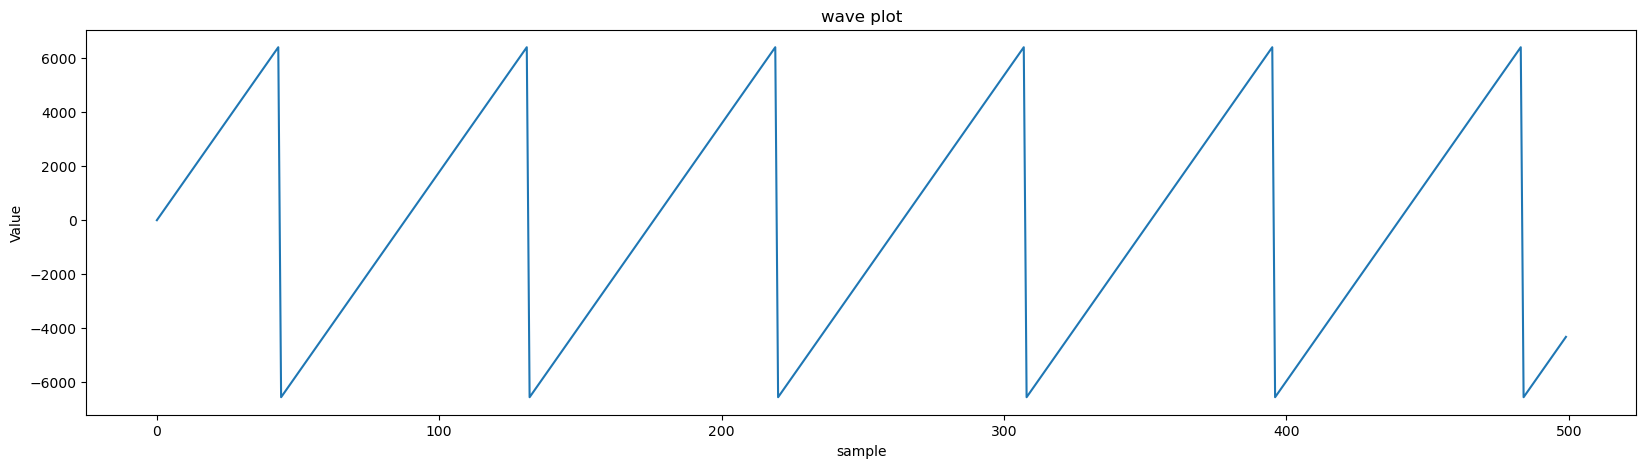

In [56]:
sampleRate = 44100
time = 1
freq = BASE_NOTES_HERTZ['C']
data = generateByteWaveTable(sampleRate,time,saw_wave,500,0.2)
plt.figure(figsize=(20, 5))  # Sets width to 10 inches, height to 6 inches
plt.plot(data[:500])
plt.xlabel('sample')
plt.ylabel('Value')
plt.title('wave plot')
plt.show()

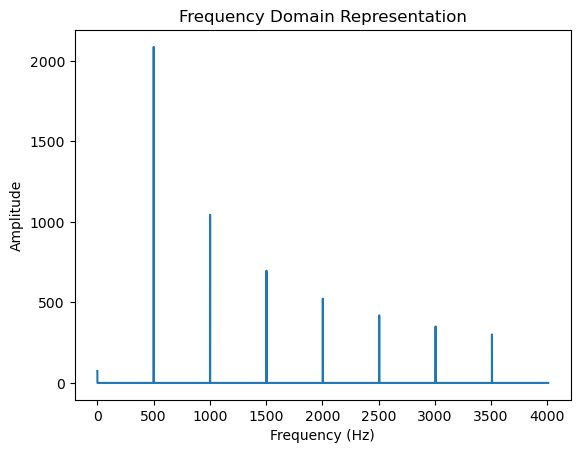

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Perform FFT
fourierTransform = np.fft.fft(data) / len(data)
fourierTransform = fourierTransform[:len(data)//2]  # Keep only positive frequencies

# Frequency axis
frequencies = np.linspace(0, sampleRate / 2, len(fourierTransform))

# Plot
plt.plot(frequencies[0:4000], np.abs(fourierTransform)[0:4000])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Frequency Domain Representation')
plt.show()

-0.39963466696683936 0.04000000000000001
1.2136487180745839 -1.6464181975194905 0.8239616497815522 0.07283446132614388 0.17679090124025476 0.07283446132614388


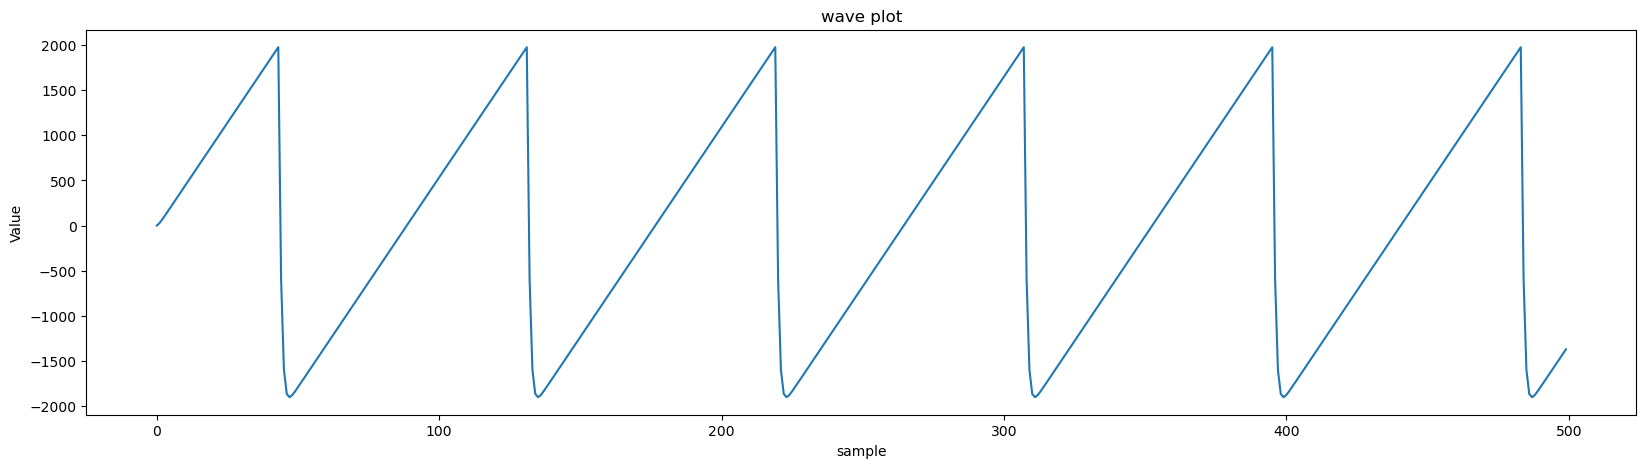

In [66]:
lp = secondOrderLowPass(300,0.2,sampleRate)
raf = runningAvarageFilter(50)
bq = BiquadLowPass(300,0.1,sampleRate)

newdata = []
for i in range(len(data)):
    newdata.append(lp.solve(data[i]))


plt.figure(figsize=(20, 5))  # Sets width to 10 inches, height to 6 inches
plt.plot(newdata[:500])
plt.xlabel('sample')
plt.ylabel('Value')
plt.title('wave plot')
write("saw_filtered.wav", sampleRate, np.array(newdata).astype(np.int16))
plt.show()   


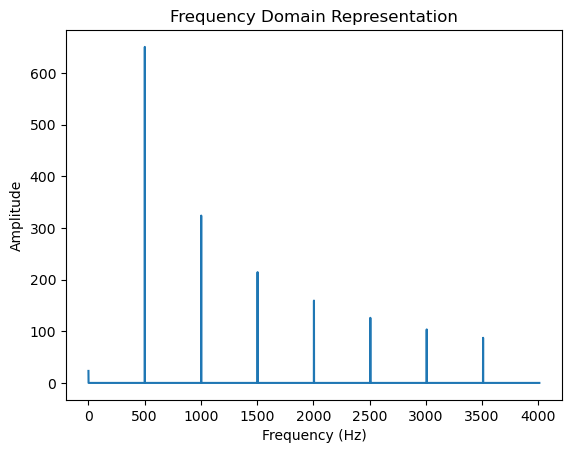

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Perform FFT
fourierTransform = np.fft.fft(newdata) / len(newdata)
fourierTransform = fourierTransform[:len(newdata)//2]  # Keep only positive frequencies

# Frequency axis
frequencies = np.linspace(0, sampleRate / 2, len(fourierTransform))

# Plot
plt.plot(frequencies[0:4000], np.abs(fourierTransform)[0:4000])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Frequency Domain Representation')
plt.show()